# Лабораторная работа №4

Выполнил Курбатов Алексей, ИВТб-2302
Вариант 10

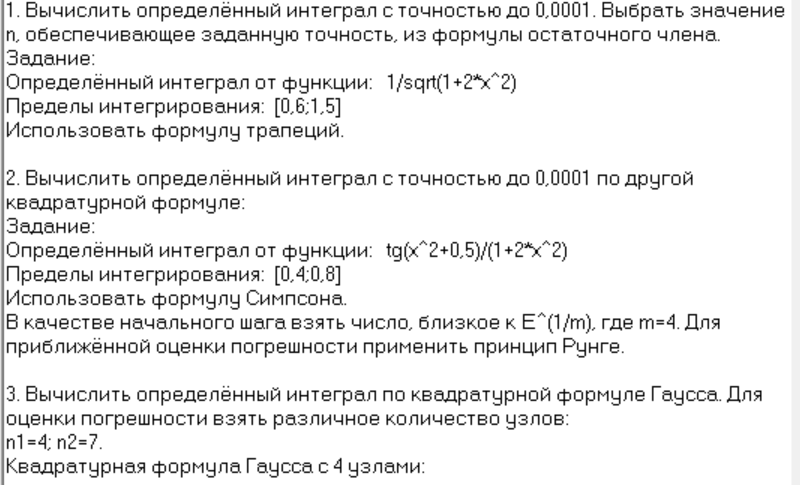
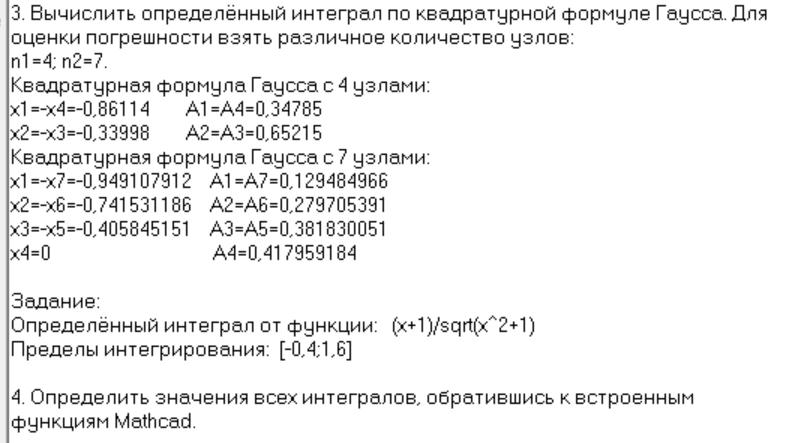
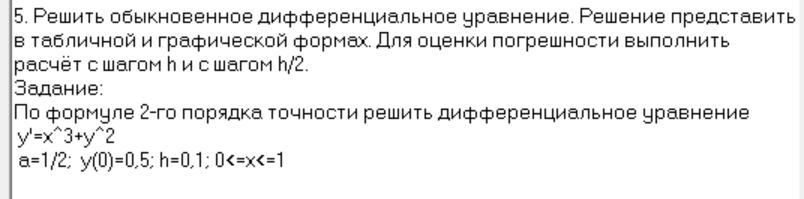

## 2 Вычислить интеграл по формуле Симпсона

In [3]:
def f(x):
    return np.tan(x**2+0.5) / (1+2*x**2)

def simpson(a, b, n):
    h = (b - a) / n
    x_val = [a + i * h for i in range(n+1)]
    integral = (h / 3) * (f(x_val[0]) + 4 * sum(f(x_val[i]) for i in range(1, n, 2)) +2 * sum(f(x_val[i]) for i in range(2, n-1, 2)) + f(x_val[n]))
    return integral

def runge(I_n, I_2n, eps):
    return abs(I_n - I_2n) < eps

a, b = 0.4, 0.8
eps = 0.0001
m = 4
h_0 = np.exp(1 / m)
h = 2
while True:
    n = max(2, int((b - a) / h))
    I_n = simpson(a, b, n)
    I_2n = simpson(a, b, 2*n)
    error_estimate = abs(I_2n - I_n) / 15
    print(f"h={h:4d}, I={I_2n:.8f}, ошибка≈{error_estimate:.8f}")
    if error_estimate < eps:
        result2 = I_2n
        final_n = 2*h
        print(f"\nТочность достигнута при h={final_n}")
        break
    else:
        h *= 2

print(f"Приближенное значение интеграла: {I_2n:.6f}")


def find_parabola_coefficients(x1, y1, x2, y2, x3, y3):
    # Главный определитель
    D = (x1**2 * (x2 - x3) +
         x2**2 * (x3 - x1) +
         x3**2 * (x1 - x2))

    # Определитель для a
    Da = (y1 * (x2 - x3) +
          y2 * (x3 - x1) +
          y3 * (x1 - x2))

    # Определитель для b
    Db = (x1**2 * (y2 - y3) +
          x2**2 * (y3 - y1) +
          x3**2 * (y1 - y2))

    # Определитель для c
    Dc = (x1**2 * (x2*y3 - x3*y2) +
          x2**2 * (x3*y1 - x1*y3) +
          x3**2 * (x1*y2 - x2*y1))

    # Коэффициенты
    a_coef = Da / D
    b_coef = Db / D
    c_coef = Dc / D

    return a_coef, b_coef, c_coef

def parabola_value(a, b, c, x):
    """Вычисление значения параболы в точке x"""
    return a*x*x + b*x + c



print("**Построение параболы через 3 точки**")


# Выбираем 3 точки на интервале [a, b]
x1, x2, x3 = a, (a+b)/2, b
y1, y2, y3 = f(x1), f(x2), f(x3)

print(f"Точка 1: ({x1:.4f}, {y1:.6f})")
print(f"Точка 2: ({x2:.4f}, {y2:.6f})")
print(f"Точка 3: ({x3:.4f}, {y3:.6f})")

# Находим коэффициенты параболы
A, B, C = find_parabola_coefficients(x1, y1, x2, y2, x3, y3)

print(f"\nУравнение параболы: P(x) = {A:.6f}x^2 + {B:.6f}x + {C:.6f}")

# Вычисляем интеграл от параболы аналитически
def integral_of_parabola(A, B, C, a, b):
    """∫(Ax² + Bx + C)dx = A·x³/3 + B·x²/2 + C·x"""
    F = lambda x: A*x**3/3 + B*x**2/2 + C*x
    return F(b) - F(a)

integral_parabola = integral_of_parabola(A, B, C, a, b)
print(f"\nИнтеграл от параболы на [{a}, {b}]: {integral_parabola:.8f}")

# ========== ГРАФИКИ ==========
# Создаем точки для построения графиков
x_plot = np.linspace(a-0.05, b+0.05, 500)
y_func = [f(x) for x in x_plot]
y_parabola = [parabola_value(A, B, C, x) for x in x_plot]

# Создаем рисунок
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Функция и парабола
ax1 = axes[0]
ax1.plot(x_plot, y_func, 'b-', linewidth=2, label='f(x)')
ax1.plot(x_plot, y_parabola, 'r--', linewidth=2, label='Парабола')
ax1.scatter([x1, x2, x3], [y1, y2, y3], color='green', s=100, zorder=5,
            label='Точки', edgecolors='black', linewidth=2)

# Закрашиваем площадь
x_fill = np.linspace(a, b, 100)
y_fill = [f(x) for x in x_fill]
ax1.fill_between(x_fill, 0, y_fill, alpha=0.3, color='blue')

ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.axvline(x=a, color='gray', linestyle='--', alpha=0.7)
ax1.axvline(x=b, color='gray', linestyle='--', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Функция и парабола через 3 точки\nИнтеграл = {I_2n:.6f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Только парабола и её точки
ax2 = axes[1]
x_zoom = np.linspace(a-0.02, b+0.02, 200)
y_zoom_p = [parabola_value(A, B, C, x) for x in x_zoom]

ax2.plot(x_zoom, y_zoom_p, 'r-', linewidth=2, label='Парабола P(x)')
ax2.scatter([x1, x2, x3], [y1, y2, y3], color='green', s=150, zorder=5,
            label='Узлы интерполяции', edgecolors='black', linewidth=2)

# Рисуем параболу как кривую
for xi in [x1, x2, x3]:
    ax2.axvline(x=xi, color='gray', linestyle=':', alpha=0.5)

ax2.set_xlabel('x')
ax2.set_ylabel('P(x)')
ax2.set_title(f'Парабола: P(x) = {A:.3f}x^2 + {B:.3f}x + {C:.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("**Проверка: парабола проходит через заданные точки**")

# Проверяем, что парабола действительно проходит через точки
print(f"P({x1:.4f}) = {parabola_value(A, B, C, x1):.8f} (должно быть {y1:.8f})")
print(f"P({x2:.4f}) = {parabola_value(A, B, C, x2):.8f} (должно быть {y2:.8f})")
print(f"P({x3:.4f}) = {parabola_value(A, B, C, x3):.8f} (должно быть {y3:.8f})")

# Вычисляем погрешность
max_error = max(abs(parabola_value(A, B, C, x) - f(x)) for x in x_plot)
print(f"\nМаксимальная ошибка аппроксимации: {max_error:.2e}")





NameError: name 'np' is not defined

## 3 Вычисление определённого интеграла по квадратурной формуле Гаусса

In [ ]:
def f3(x):
    return (x + 1) / np.sqrt(x**2 + 1)

def gauss_quadrature(a, b, nodes, weights):
    transform = lambda t: (b - a) / 2 * t + (b + a) / 2
    integral = (b - a) / 2 * np.sum(weights * f3(transform(nodes)))
    return integral

# Узлы и веса (n=4)
nodes_4 = np.array([-0.86114, -0.33998, 0.33998, 0.86114])
weights_4 = np.array([0.34785, 0.65215, 0.65215, 0.34785])

# Узлы и веса (n=7)
nodes_7 = np.array([-0.949107912, -0.741531186, -0.405845151, 0.0,
                     0.405845151, 0.741531186, 0.949107912])
weights_7 = np.array([0.129484966, 0.279705391, 0.381830051, 0.417959184,
                      0.381830051, 0.279705391, 0.129484966])

a, b = -0.4, 1.6

I4 = gauss_quadrature(a, b, nodes_4, weights_4)
I7 = gauss_quadrature(a, b, nodes_7, weights_7)

print(f"Интеграл по формуле Гаусса (n=4): {I4:.8f}")
print(f"Интеграл по формуле Гаусса (n=7): {I7:.8f}")
print(f"Оценка погрешности (|I7 - I4|): {abs(I7 - I4):.8f}")

In [ ]:
def f3_1(x): # многочлен пятой степени
    return x**5 - 2*x**4 + 3*x**3 - 4*x**2 + 5*x - 6

def gauss_quadrature_1(a, b, nodes, weights):
    transform = lambda t: (b - a) / 2 * t + (b + a) / 2
    integral = (b - a) / 2 * np.sum(weights * f3_1(transform(nodes)))
    return integral

a, b = -1.0, 1.0

I4 = gauss_quadrature_1(a, b, nodes_4, weights_4)
I7 = gauss_quadrature_1(a, b, nodes_7, weights_7)

print(f"Интеграл по формуле Гаусса (n=4): {I4:.8f}")
print(f"Интеграл по формуле Гаусса (n=7): {I7:.8f}")
print(f"Оценка погрешности (|I7 - I4|): {abs(I7 - I4):.8f}")

In [ ]:
def f3_2(x): # 11 степень
    return x**12

def gauss_quadrature_1(a, b, nodes, weights):
    transform = lambda t: (b - a) / 2 * t + (b + a) / 2
    integral = (b - a) / 2 * np.sum(weights * f3_2(transform(nodes)))
    return integral

a, b = -1.0, 1.0

I4 = gauss_quadrature_1(a, b, nodes_4, weights_4)
I7 = gauss_quadrature_1(a, b, nodes_7, weights_7)

print(f"Интеграл по формуле Гаусса (n=4): {I4:.8f}")
print(f"Интеграл по формуле Гаусса (n=7): {I7:.8f}")
print(f"Оценка погрешности (|I7 - I4|): {abs(I7 - I4):.8f}")

## 4 Решение обыкновенного дифференциального уравнения

In [ ]:
def f(x, y):
    return x**3 + y**2

def euler_second_order(a, b, y0, h):
    x_values = [a]
    y_values = [y0]
    n = int((b - a) / h)
    x = a
    y = y0
    for _ in range(n):
        k1 = f(x, y)
        k2 = f(x + h, y + h * k1)
        y = y + (h / 2) * (k1 + k2)
        x += h
        x_values.append(x)
        y_values.append(y)
    return x_values, y_values

a, b = 0.0, 1.0
y0 = 0.5
h1 = 0.1
h2 = 0.05

x_h1, y_h1 = euler_second_order(a, b, y0, h1)
x_h2, y_h2 = euler_second_order(a, b, y0, h2)

# Оценка погрешности по правилу Рунге
error = [abs(y_h1[i] - y_h2[2 * i]) / 3 for i in range(len(y_h1))]

print("Результаты для h=0.1:")
print("    x        y(x)")
for i in range(len(x_h1)):
    print(f"{x_h1[i]:6.2f}    {y_h1[i]:.8f}")

print("\nРезультаты для h=0.05 (каждая вторая точка):")
print("    x        y(x)")
for i in range(0, len(x_h2), 2):
    print(f"{x_h2[i]:6.2f}    {y_h2[i]:.8f}")

print("\nОценка погрешности по правилу Рунге:")
print("    x      погрешность")
for i in range(len(x_h1)):
    print(f"{x_h1[i]:6.2f}    {error[i]:.8f}")

print(f"\nМаксимальная погрешность: {max(error):.8f}")
print(f"Средняя погрешность: {sum(error)/len(error):.8f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_h1, y_h1, 'bo-', linewidth=2, markersize=6, label='h = 0.1')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Решение ОДУ (шаг h = 0.1)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

# ========== ГРАФИК 2: Решение с шагом h = 0.05 ==========
plt.subplot(1, 2, 2)
plt.plot(x_h2, y_h2, 'ro-', linewidth=2, markersize=4, label='h = 0.05')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Решение ОДУ (шаг h = 0.05)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

plt.plot(x_h1, y_h1, 'bo-', label='h=0.1')
plt.plot(x_h2, y_h2, 'ro-', label='h=0.05')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Численное решение ОДУ методом Эйлера 2-го порядка')
plt.grid()
plt.show()